In [23]:
import os.path as op
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne
from scipy import stats
from functools import partial

In [4]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [5]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [8]:
short_color=np.array([255,0,0])/255.0
long_color=np.array([0,0,255])/255.0

td_color=np.array([27,158,119])/255.0
asd_color=np.array([117,112,179])/255.0

ipsi_color=np.array([90,180,172])/255.0
contra_color=np.array([216,179,101])/255.0

In [13]:
all_beta_power={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

In [15]:
print(len(all_beta_power[hemi][epo_type][condition_name]))

70


In [16]:
t_idx=np.where((power_time>=-.5) & (power_time<=1))[0]
base_idx=np.where(power_time[t_idx]<0)[0]
        
beta_pow_bc={
    group: {
        epoch: {
            condition: {
                hemi: [] for hemi in ['contra','ipsi']
            } for condition in ['SHORT','LONG']
        } for epoch in ['STIM','RESP']
    } for group in ['TD','ASD']
}

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:
            base_pow=np.mean(all_beta_power[hemi]['STIM']['LONG'][s_idx][t_idx][base_idx])
            for condition in ['SHORT','LONG']:
                for epoch in ['STIM','RESP']:
                    b_pow=all_beta_power[hemi][epoch][condition][s_idx][t_idx]
                    b_pow=(b_pow-base_pow)/base_pow*100
                    beta_pow_bc[group][epoch][condition][hemi].append(b_pow)
        
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:
            base_pow=np.mean(all_beta_power[hemi]['STIM']['LONG'][s_idx][t_idx][base_idx])
            for condition in ['SHORT','LONG']:
                for epoch in ['STIM','RESP']:
                    b_pow=all_beta_power[hemi][epoch][condition][s_idx][t_idx]
                    b_pow=(b_pow-base_pow)/base_pow*100
                    beta_pow_bc[group][epoch][condition][hemi].append(b_pow)                
                
for group in ['TD','ASD']:
    for hemi in ['contra','ipsi']:
        for condition in ['SHORT','LONG']:
            for epoch in ['STIM','RESP']:
                beta_pow_bc[group][epoch][condition][hemi]=np.array(beta_pow_bc[group][epoch][condition][hemi])
                
n_td=beta_pow_bc['TD']['RESP']['LONG']['contra'].shape[0]
n_asd=beta_pow_bc['ASD']['RESP']['LONG']['contra'].shape[0]
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=37


stat_fun(H1): min=0.000005 max=2.619526
Running initial clustering …
Using 262 thresholds from 0.00 to 2.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000000 max=2.880008
Running initial clustering …
Using 289 thresholds from 0.00 to 2.88 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000002 max=2.207876
Running initial clustering …
Using 221 thresholds from 0.00 to 2.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000000 max=2.588401
Running initial clustering …
Using 259 thresholds from 0.00 to 2.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000000 max=1.545848
Running initial clustering …
Using 155 thresholds from 0.00 to 1.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

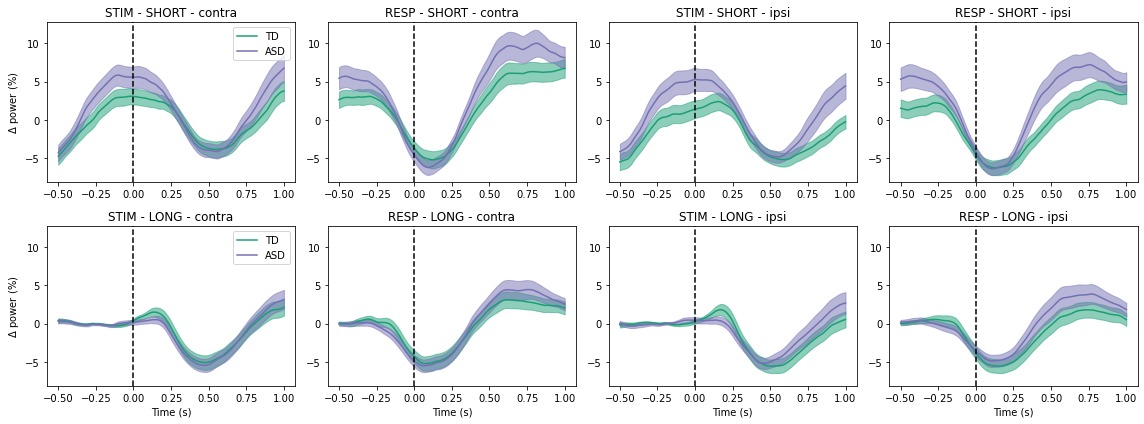

In [27]:
plt.figure(figsize=(16,6))

# Define condition combinations and axes
conditions = [
    ('STIM', 'SHORT', 'contra', plt.subplot(2,4,1), 'STIM - SHORT - contra'),
    ('RESP', 'SHORT', 'contra', plt.subplot(2,4,2), 'RESP - SHORT - contra'),
    ('STIM', 'LONG',  'contra', plt.subplot(2,4,5), 'STIM - LONG - contra'),
    ('RESP', 'LONG',  'contra', plt.subplot(2,4,6), 'RESP - LONG - contra'),
    ('STIM', 'SHORT', 'ipsi',  plt.subplot(2,4,3), 'STIM - SHORT - ipsi'),
    ('RESP', 'SHORT', 'ipsi',  plt.subplot(2,4,4), 'RESP - SHORT - ipsi'),
    ('STIM', 'LONG',  'ipsi',  plt.subplot(2,4,7), 'STIM - LONG - ipsi'),
    ('RESP', 'LONG',  'ipsi',  plt.subplot(2,4,8), 'RESP - LONG - ipsi')
]

threshold_tfce = dict(start=0, step=0.01)
all_axes = []

for evt, dur, hemi, ax, title in conditions:
    # TD
    m_pow = np.mean(beta_pow_bc['TD'][evt][dur][hemi], axis=0)
    se_pow = np.std(beta_pow_bc['TD'][evt][dur][hemi], axis=0) / np.sqrt(beta_pow_bc['TD'][evt][dur][hemi].shape[0])
    ax.plot(power_time[t_idx], m_pow, label='TD', color=td_color)
    ax.fill_between(power_time[t_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=td_color)

    # ASD
    m_pow = np.mean(beta_pow_bc['ASD'][evt][dur][hemi], axis=0)
    se_pow = np.std(beta_pow_bc['ASD'][evt][dur][hemi], axis=0) / np.sqrt(beta_pow_bc['ASD'][evt][dur][hemi].shape[0])
    ax.plot(power_time[t_idx], m_pow, label='ASD', color=asd_color)
    ax.fill_between(power_time[t_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=asd_color)

    # Unpaired cluster permutation test
#     data = [beta_pow_bc['TD'][evt][dur][hemi], beta_pow_bc['ASD'][evt][dur][hemi]]
    data = [beta_pow_bc['ASD'][evt][dur][hemi], beta_pow_bc['TD'][evt][dur][hemi]]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        data,
        threshold=threshold_tfce,
        n_permutations=1000,
        tail=0
    )

    # Plot significant clusters
    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - 0)
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(power_time[t_idx][p_idx], py, 'k*')

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(title)
    if (hemi == 'contra' and evt == 'STIM' and dur == 'SHORT') or (hemi == 'contra' and evt == 'STIM' and dur == 'LONG'):
        ax.legend()
        ax.set_ylabel(r'$\Delta$ power (%)')
    if dur == 'LONG':
        ax.set_xlabel('Time (s)')

    all_axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in all_axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in all_axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()

stat_fun(H1): min=-4.215880 max=3.642673
Running initial clustering …
Using 422 thresholds from 0.00 to 4.21 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.305727 max=5.532940
Running initial clustering …
Using 554 thresholds from 0.00 to 5.53 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.535606 max=2.394962
Running initial clustering …
Using 454 thresholds from 0.00 to 4.53 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.750251 max=3.432515
Running initial clustering …
Using 376 thresholds from 0.00 to 3.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.618876 max=3.733190
Running initial clustering …
Using 374 thresholds from 0.00 to 3.73 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

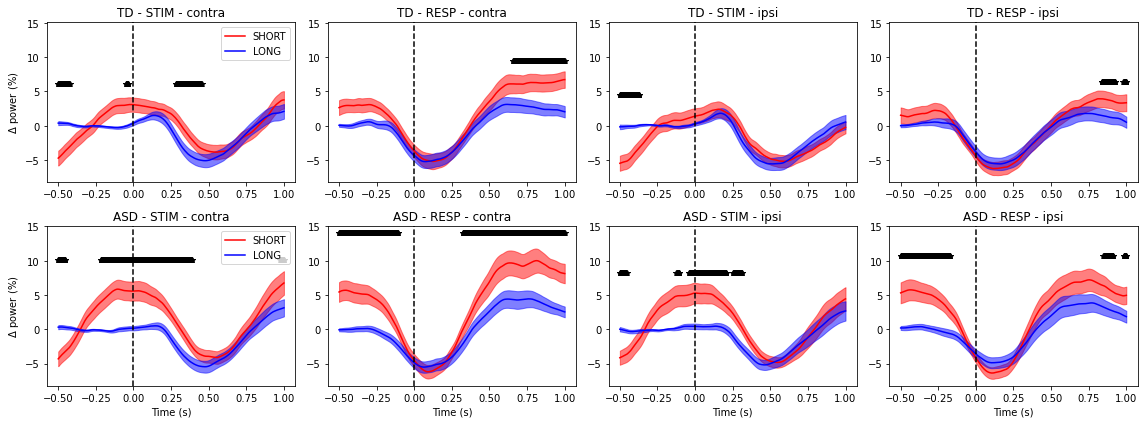

In [24]:
plt.figure(figsize=(16,6))

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

# Define all subplot conditions
conditions = [
    ('TD', 'STIM', 'contra', 'TD - STIM - contra', 1),
    ('TD', 'RESP', 'contra', 'TD - RESP - contra', 2),
    ('TD', 'STIM', 'ipsi',  'TD - STIM - ipsi', 3),
    ('TD', 'RESP', 'ipsi',  'TD - RESP - ipsi', 4),
    ('ASD', 'STIM', 'contra', 'ASD - STIM - contra', 5),
    ('ASD', 'RESP', 'contra', 'ASD - RESP - contra', 6),
    ('ASD', 'STIM', 'ipsi',  'ASD - STIM - ipsi', 7),
    ('ASD', 'RESP', 'ipsi',  'ASD - RESP - ipsi', 8)
]

axes = []
for grp, evt, hemi, title, pos in conditions:
    ax = plt.subplot(2, 4, pos)

    # Plot SHORT
    m_pow = np.mean(beta_pow_bc[grp][evt]['SHORT'][hemi], axis=0)
    se_pow = np.std(beta_pow_bc[grp][evt]['SHORT'][hemi], axis=0) / np.sqrt(beta_pow_bc[grp][evt]['SHORT'][hemi].shape[0])
    ax.plot(power_time[t_idx], m_pow, label='SHORT', color=short_color)
    ax.fill_between(power_time[t_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=short_color)

    # Plot LONG
    m_pow = np.mean(beta_pow_bc[grp][evt]['LONG'][hemi], axis=0)
    se_pow = np.std(beta_pow_bc[grp][evt]['LONG'][hemi], axis=0) / np.sqrt(beta_pow_bc[grp][evt]['LONG'][hemi].shape[0])
    ax.plot(power_time[t_idx], m_pow, label='LONG', color=long_color)
    ax.fill_between(power_time[t_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=long_color)

    # Paired t-test
    data = [beta_pow_bc[grp][evt]['SHORT'][hemi], beta_pow_bc[grp][evt]['LONG'][hemi]]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        data,
        stat_fun=paired_t,
        threshold=threshold_tfce,
        n_permutations=1000,
        tail=0
    )

    # Plot significant clusters
    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - 0)
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(power_time[t_idx][p_idx], py, 'k*')

    # Formatting
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(title)

    # Add legend and labels for the first subplot
    if evt == 'STIM' and hemi == 'contra':
        ax.legend()
        ax.set_ylabel(r'$\Delta$ power (%)')

    # Label bottom row axes
    if grp == 'ASD':
        ax.set_xlabel('Time (s)')

    axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()


stat_fun(H1): min=0.044193 max=4.581593
Running initial clustering …
Using 459 thresholds from 0.00 to 4.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.367804 max=4.867918
Running initial clustering …
Using 487 thresholds from 0.00 to 4.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.738370 max=3.747706
Running initial clustering …
Using 375 thresholds from 0.00 to 3.74 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.623771 max=2.090781
Running initial clustering …
Using 210 thresholds from 0.00 to 2.09 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.527826 max=1.670138
Running initial clustering …
Using 253 thresholds from 0.00 to 2.52 for TFCE computation (h_power=2.00, e_power=0.50)
Found 901 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

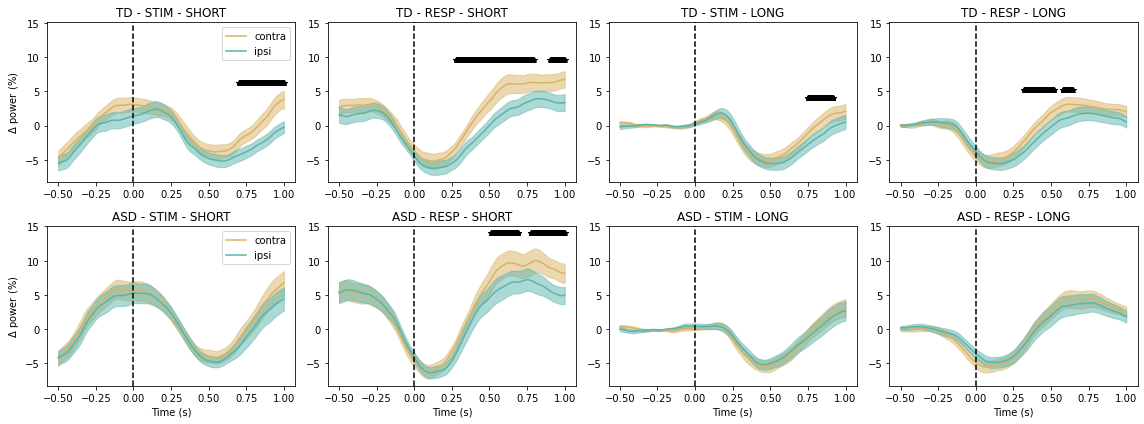

In [25]:
plt.figure(figsize=(16,6))

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

# Define all subplot conditions
conditions = [
    ('TD', 'STIM', 'SHORT', 'TD - STIM - SHORT', 1),
    ('TD', 'RESP', 'SHORT', 'TD - RESP - SHORT', 2),
    ('TD', 'STIM', 'LONG',  'TD - STIM - LONG', 3),
    ('TD', 'RESP', 'LONG',  'TD - RESP - LONG', 4),
    ('ASD', 'STIM', 'SHORT', 'ASD - STIM - SHORT', 5),
    ('ASD', 'RESP', 'SHORT', 'ASD - RESP - SHORT', 6),
    ('ASD', 'STIM', 'LONG',  'ASD - STIM - LONG', 7),
    ('ASD', 'RESP', 'LONG',  'ASD - RESP - LONG', 8)
]

axes = []
for grp, evt, dur, title, pos in conditions:
    ax = plt.subplot(2, 4, pos)

    # Plot SHORT
    m_pow = np.mean(beta_pow_bc[grp][evt][dur]['contra'], axis=0)
    se_pow = np.std(beta_pow_bc[grp][evt][dur]['contra'], axis=0) / np.sqrt(beta_pow_bc[grp][evt][dur]['contra'].shape[0])
    ax.plot(power_time[t_idx], m_pow, label='contra', color=contra_color)
    ax.fill_between(power_time[t_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=contra_color)

    # Plot LONG
    m_pow = np.mean(beta_pow_bc[grp][evt][dur]['ipsi'], axis=0)
    se_pow = np.std(beta_pow_bc[grp][evt][dur]['ipsi'], axis=0) / np.sqrt(beta_pow_bc[grp][evt][dur]['ipsi'].shape[0])
    ax.plot(power_time[t_idx], m_pow, label='ipsi', color=ipsi_color)
    ax.fill_between(power_time[t_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=ipsi_color)

    # Paired t-test
    data = [beta_pow_bc[grp][evt][dur]['contra'], beta_pow_bc[grp][evt][dur]['ipsi']]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        data,
        stat_fun=paired_t,
        threshold=threshold_tfce,
        n_permutations=1000,
        tail=0
    )

    # Plot significant clusters
    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - 0)
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(power_time[t_idx][p_idx], py, 'k*')

    # Formatting
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(title)

    # Add legend and labels for the first subplot
    if evt == 'STIM' and dur == 'SHORT':
        ax.legend()
        ax.set_ylabel(r'$\Delta$ power (%)')

    # Label bottom row axes
    if grp == 'ASD':
        ax.set_xlabel('Time (s)')

    axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
